In [ ]:
# %%

# 0. load libraries
import os
os.chdir("/hpc/home/yx306/RDR")
os.getcwd()


import numpy as np
import matplotlib.pyplot as plt
import utils.help_func as help
import torch
import utils.DRE_func as dre
from matplotlib.colors import TwoSlopeNorm
from importlib import reload

# for reproducibility
SEED = 123

import random
random.seed(SEED)          # Python built-in
np.random.seed(SEED)       # NumPy
torch.manual_seed(SEED)    # PyTorch (CPU)
torch.cuda.manual_seed_all(SEED)  # PyTorch (all GPU devices)


# (optional but recommended for strict reproducibility)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

/hpc/home/yx306/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch    0: Loss = 0.005670
Epoch  100: Loss = 0.000043
Epoch  200: Loss = 0.000001
Epoch  300: Loss = 0.000001
Epoch  400: Loss = 0.000001
Epoch  500: Loss = 0.000001
Epoch  600: Loss = 0.000001
Epoch  700: Loss = 0.000001
Epoch  800: Loss = 0.000001
Epoch  900: Loss = 0.000001
Epoch    0: Loss = 0.006802
Epoch  100: Loss = 0.000039
Epoch  200: Loss = 0.000008
Epoch  300: Loss = 0.000002
Epoch  400: Loss = 0.000002
Epoch  500: Loss = 0.000002
Epoch  600: Loss = 0.000002
Epoch  700: Loss = 0.000002
Epoch  800: Loss = 0.000002
Epoch  900: Loss = 0.000002
Epoch    0: Loss = 0.005263
Epoch  100: Loss = -0.083104
Epoch  200: Loss = -0.107177
Epoch  300: Loss = -0.107998
Epoch  400: Loss = -0.108347
Epoch  500: Loss = -0.108569
Epoch  600: Loss = -0.108715
Epoch  700: Loss = -0.108834
Epoch  800: Loss = -0.108941
Epoch  900: Loss = -0.109029
Epoch    0: Loss = 0.010570
Epoch  100: Loss = -0.225813
Epoch  200: Loss = -0.273342
Epoch  300: Loss = -0.278827
Epoch  400: Loss = -0.281670
Epoch  

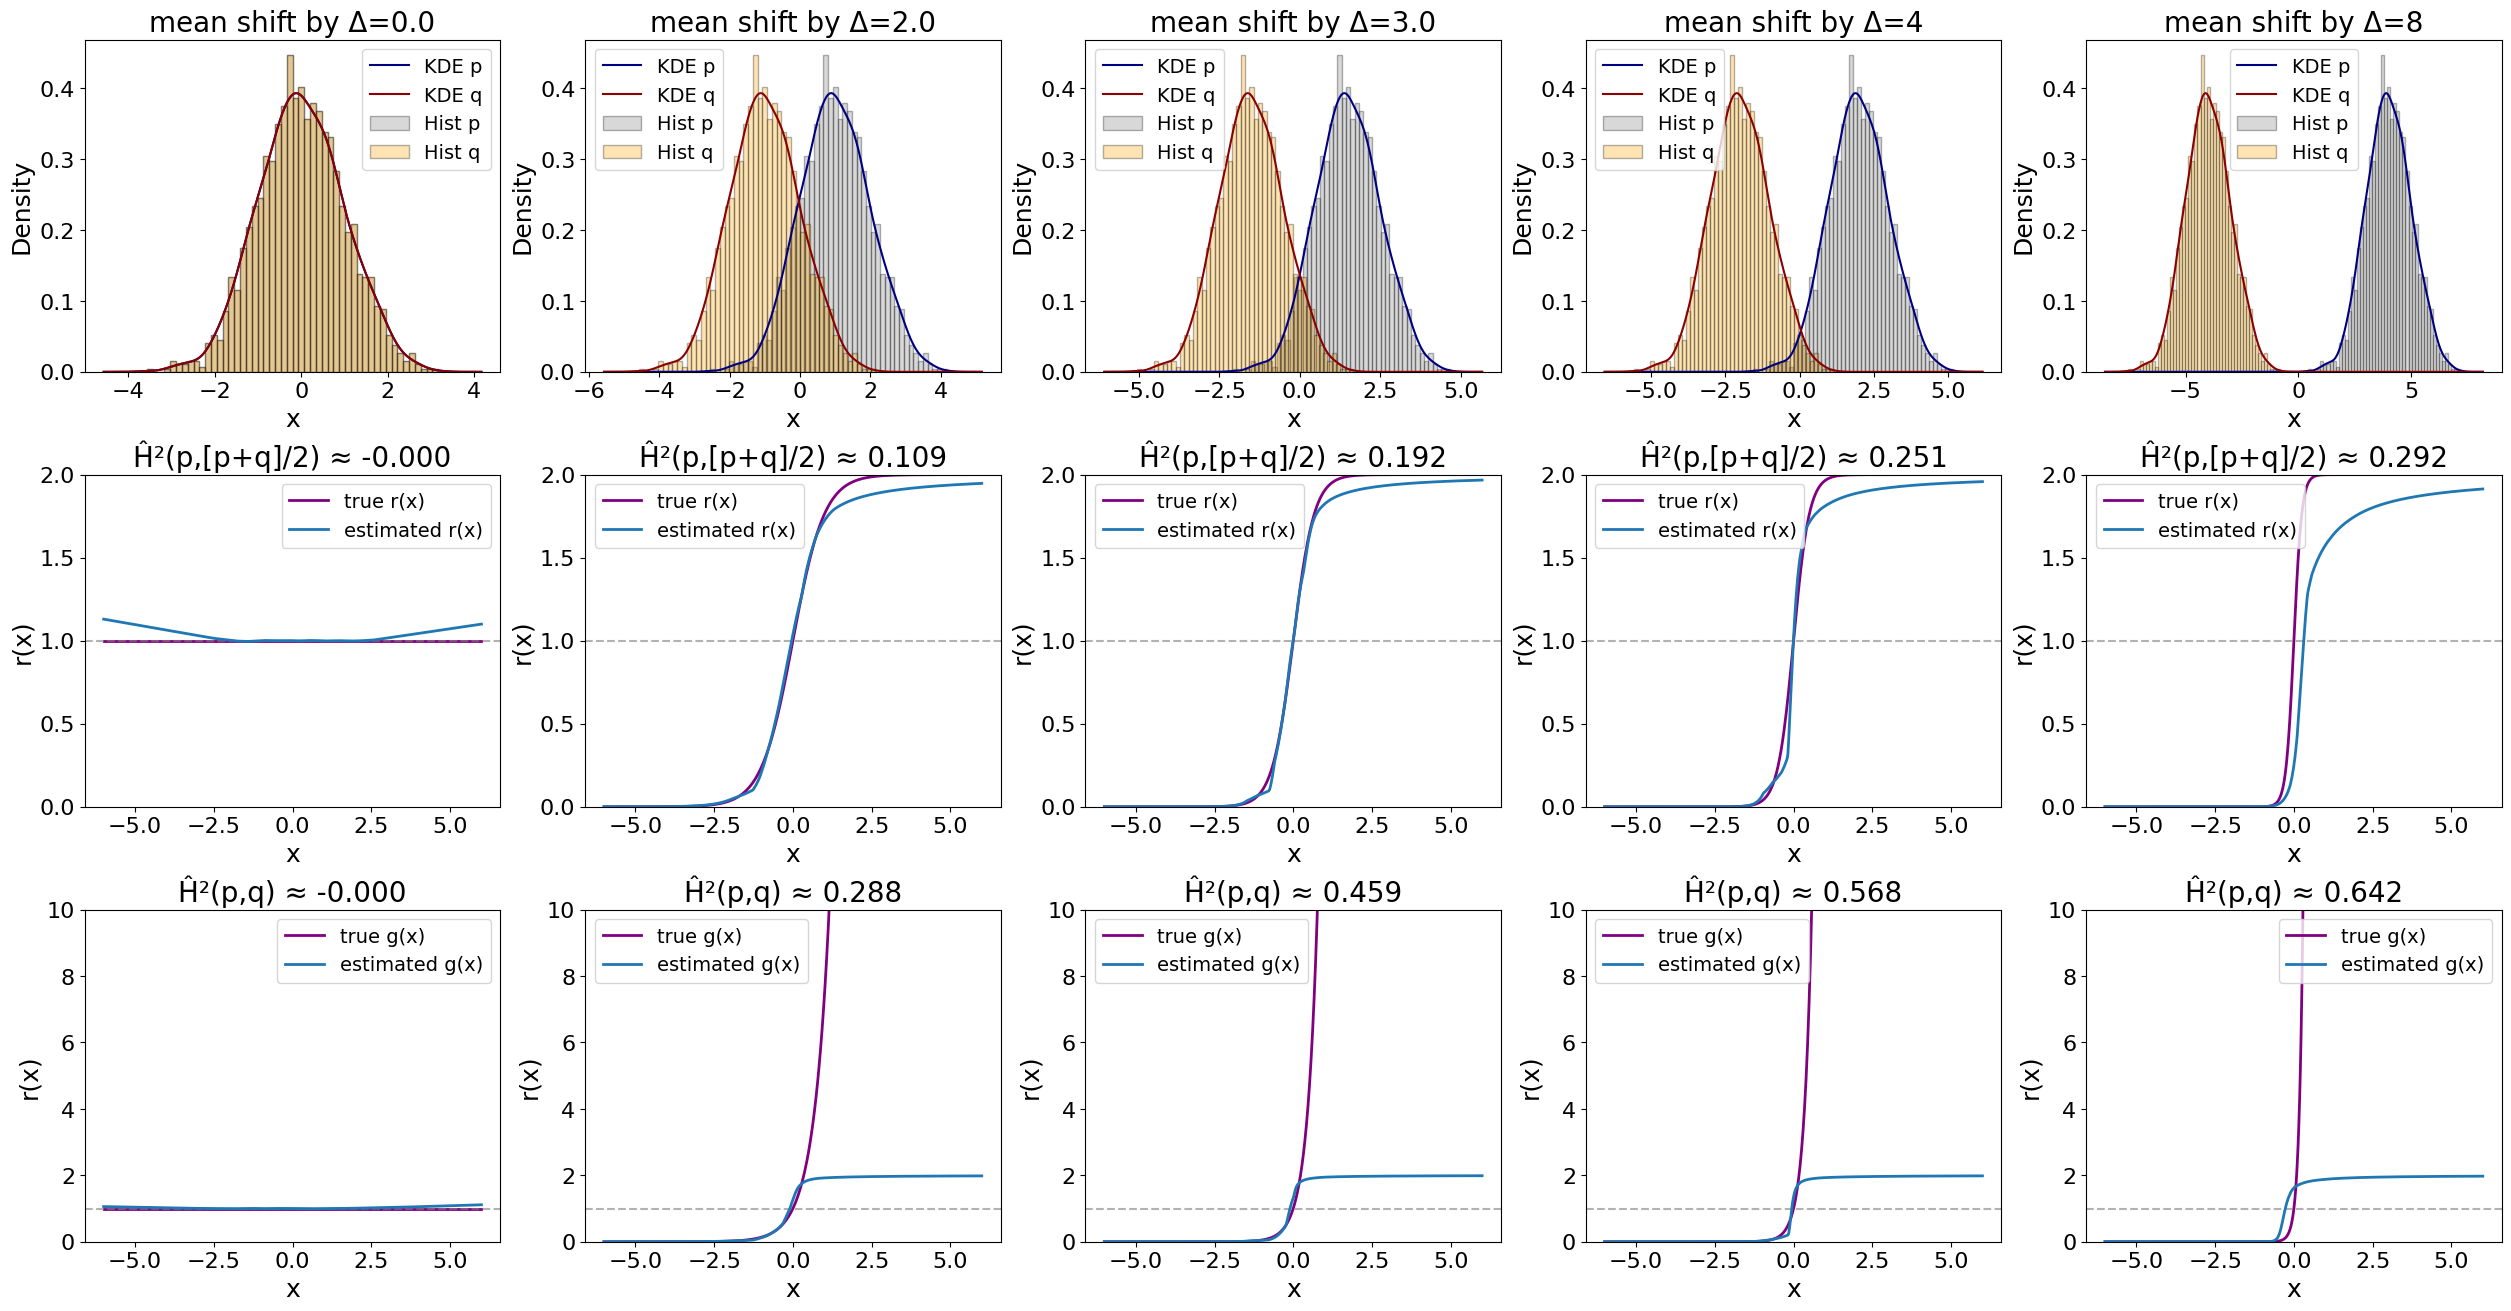

In [ ]:
# %%

# 1D example: g r tail comparison
reload(dre)
reload(help)
# sweep values
# deltas = [0.0, 0.5, 1.0, 1.5, 2, 3,4]
deltas = [0.0,  1.0, 1.5, 2, 4]

# reproducibility
SEED = 123
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
Y_grid = torch.linspace(-6, 6, steps=500).reshape(-1, 1)

# your mixture settings (example placeholders — keep yours)
n1_samples = 2000
n2_samples = 2000        

weights = [1,0,0]
covariances1 = np.array([1,1,1])
covariances2 = np.array([1,1,1])

# a helper to build a common evaluation grid around both samples
def make_eval_grid(y1, y2, pad=1.0, n=800):
    lo = min(np.min(y1), np.min(y2)) - pad
    hi = max(np.max(y1), np.max(y2)) + pad
    return np.linspace(lo, hi, n).astype(np.float32)


plt.rcParams.update({
    "font.size": 18,        # default text size
    "axes.titlesize": 20,   # axes title
    "axes.labelsize": 18,   # x and y labels
    "xtick.labelsize": 16,  # tick labels
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
})

h_size = 5*len(deltas)
fig, axes = plt.subplots(3, len(deltas), figsize=(h_size, 13), constrained_layout=True)

for col, delta in enumerate(deltas):
    # 1) define means perturbed by ±delta
    means1 = np.array([0,0,0]) + delta
    means2 = np.array([0,0,0]) - delta

    Y1,Z1 = help.sample_mixture_normals(n1_samples, weights, means1, covariances1, rng = SEED)
    Y2,Z2 = help.sample_mixture_normals(n2_samples, weights, means2, covariances2, rng = SEED)

    

    # 4) train your DRE model (make sure inputs are tensors and pass p,q separately)
    num_epochs = 1000
    x_p = torch.from_numpy(np.asarray(Y1, dtype=np.float32)).reshape(-1, 1)
    x_q = torch.from_numpy(np.asarray(Y2, dtype=np.float32)).reshape(-1, 1)
    x_mixed = torch.cat([x_p, x_q], dim=0) 

    num_epochs = 1000
    x_p = torch.from_numpy(np.array(Y1, dtype = np.float32))
    x_q = torch.from_numpy(np.array(Y2, dtype = np.float32))

    x_mixed = torch.cat([x_p, x_q], dim=0) 
    model_r, losses_r = dre.run_DRE_fdiv(x_p,x_mixed,xi=0.5,
                                    num_epochs = num_epochs,
                                    log_scale = False,
                                    loss_method='Hellinger')
    model_g, losses_g = dre.run_DRE_fdiv(x_p,x_q,xi=0.5,
                                    num_epochs = num_epochs,
                                    log_scale = False,
                                    loss_method='Hellinger')

    # 3) left plot: empirical densities
    axL = axes[0, col]
    help.plot_1d_density_compare(Y1, Y2, labels=("p", "q"),
                                 title=f"mean shift by Δ={2*delta}",
                                 ax=axL)

    with torch.no_grad():
        w_vis_r = model_r(Y_grid)
        w_vis_g = model_g(Y_grid)

    w_vis_np_r = w_vis_r.detach().numpy()
    w_vis_np_g = w_vis_g.detach().numpy()

    ratios_r = help.density_ratio(Y_grid,weights,means1,means2,
                                covariances1,covariances2, mixed=True)

    ratios_g = help.density_ratio(Y_grid,weights,means1,means2,
                                covariances1,covariances2, mixed=False)

    # 6) estimate the last-epoch average (robust to short histories)
    steps_per_epoch = 100
    tail = losses_r[-steps_per_epoch:] if len(losses_r) >= steps_per_epoch else losses
    r_mean_last_epoch = float(np.mean(tail))
    tail = losses_g[-steps_per_epoch:] if len(losses_g) >= steps_per_epoch else losses
    g_mean_last_epoch = float(np.mean(tail))

    # r(x)
    axR = axes[1, col]
    help.plot_theoretical_ratio(
        Y_grid, ratios_r,
        label="true r(x)",
        ylim = [0,2],
        title=f"Ĥ²(p,[p+q]/2) ≈ {(-r_mean_last_epoch):.3f}",
        ax=axR
    )
    help.add_density_ratio_line(Y_grid, w_vis_np_r,
                                    label="estimated r(x)", ax=axR)

    axR.legend(loc="best")
    
    # g(x)
    axR = axes[2, col]
    help.plot_theoretical_ratio(
        Y_grid, ratios_g,
        label="true g(x)",
        ylim = [0,10],
        title=f"Ĥ²(p,q) ≈ {(-g_mean_last_epoch):.3f}",
        ax=axR
    )
    help.add_density_ratio_line(Y_grid, w_vis_np_g,
                                    label="estimated g(x)", ax=axR)

    axR.legend(loc="best")



plt.show()

Epoch    0: Loss = 0.005722
Epoch  300: Loss = -0.126989
Epoch  600: Loss = -0.138841
Epoch  900: Loss = -0.142169
Epoch 1200: Loss = -0.142473
Epoch 1500: Loss = -0.142510
Epoch 1800: Loss = -0.142519
Epoch 2100: Loss = -0.142525
Epoch 2400: Loss = -0.142528
Epoch 2700: Loss = -0.142530
Epoch    0: Loss = 0.005616
Epoch  300: Loss = -0.040994
Epoch  600: Loss = -0.045978
Epoch  900: Loss = -0.046513
Epoch 1200: Loss = -0.047092
Epoch 1500: Loss = -0.047319
Epoch 1800: Loss = -0.047446
Epoch 2100: Loss = -0.047522
Epoch 2400: Loss = -0.047597
Epoch 2700: Loss = -0.047622
Epoch    0: Loss = 0.004422
Epoch  300: Loss = -0.091033
Epoch  600: Loss = -0.096149
Epoch  900: Loss = -0.101915
Epoch 1200: Loss = -0.116149
Epoch 1500: Loss = -0.116572
Epoch 1800: Loss = -0.116610
Epoch 2100: Loss = -0.117101
Epoch 2400: Loss = -0.117213
Epoch 2700: Loss = -0.117246


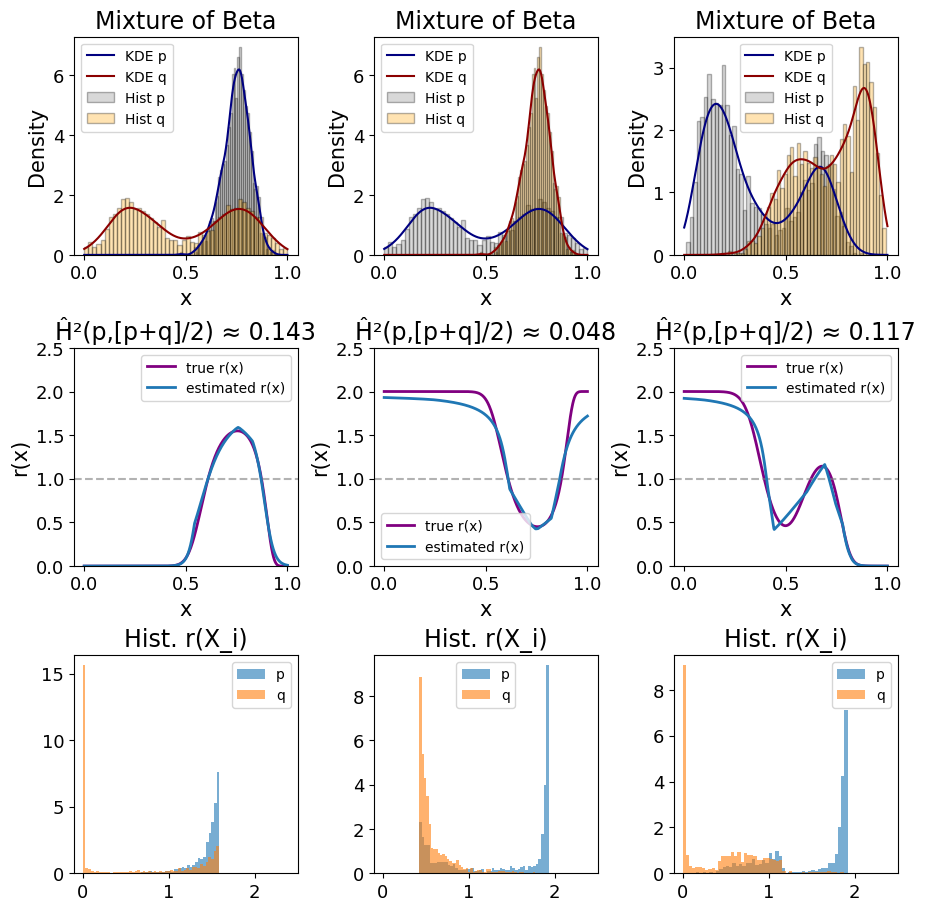

In [ ]:
# %%

# 1D Beta example: precision-recall
n = 2000
plt.rcParams.update({
    "font.size": 15,        # default text size
    "axes.titlesize": 17,   # axes title
    "axes.labelsize": 15,   # x and y labels
    "xtick.labelsize": 13,  # tick labels
    "ytick.labelsize": 13,
    "legend.fontsize": 10,
})

fig, axes = plt.subplots(3, 3, figsize=(9,9), constrained_layout=True)

# well-separated
weights = [1/3,1/3,1/3]
params_list = [
    # Left column (blue: P unimodal, Q bimodal)
    {
        "alphas1": [30, 1, 1],
        "betas1":  [10, 1, 1],
        "alphas2": [5, 15, 1],
        "betas2":  [15, 5, 1],
        "weights1": [1,0,0],
        "weights2": [1/3,1/3,1/3],
    },
    # Middle column (green: P bimodal, Q unimodal)
    {
        "alphas1": [5, 15, 1],
        "betas1":  [15, 5, 1],
        "alphas2": [30, 1, 1],
        "betas2":  [10, 1, 1],
        "weights1": [1/3,1/3,1/3],
        "weights2": [1,0,0],
    },
    # Right column (red: P trimodal, Q multimodal)
    {
        "alphas1": [3, 3, 30],
        "betas1":  [14, 5, 15],
        "alphas2": [11, 15, 20],
        "betas2":  [9, 5, 3],
        "weights1": [0.55, 0.15, 0.30],
        "weights2": [0.40, 0.15, 0.45],
    }
]


for col, params in enumerate(params_list):
    alphas1, betas1, weights1 = params["alphas1"], params["betas1"], params["weights1"]
    alphas2, betas2, weights2= params["alphas2"], params["betas2"], params["weights2"]
    Y1, z1 = help.sample_mixture_betas(n, weights1, alphas1, betas1, rng=SEED)
    Y2, z2 = help.sample_mixture_betas(n, weights2, alphas2, betas2, rng=SEED)

    axL = axes[0,col]
    help.plot_1d_density_compare(Y1, Y2, labels=("p", "q"),
                                x_lim = [0,1],
                                 title=f"Mixture of Beta",
                                 ax = axL)


    num_epochs = 3000
    x_p = torch.from_numpy(np.array(Y1, dtype = np.float32))
    x_q = torch.from_numpy(np.array(Y2, dtype = np.float32))

    x_mixed = torch.cat([x_p, x_q], dim=0) 
    model, losses = dre.run_DRE_fdiv(x_p,x_mixed,xi=0.5,
                                    num_epochs = num_epochs,
                                    log_scale = False,
                                    loss_method='Hellinger')


    stacked_Y = np.vstack([Y1,Y2])
    stacked_Y_tensor = torch.from_numpy(stacked_Y).float()

    # Y_grid = stacked_Y_tensor
    Y_grid = torch.linspace(0, 1, steps=500).reshape(-1, 1)
    with torch.no_grad():
        w_vis = model(Y_grid)
        w_vis_train = model(stacked_Y_tensor)

    w_vis_np = w_vis.detach().numpy().ravel()
    w_vis_train_np = w_vis_train.detach().numpy().ravel()

    ratios = help.beta_density_ratio(Y_grid, weights1,     
                                    alphas1, betas1,
                                    alphas2, betas2, mixed=True,
                                    weights2 = weights2)
                                    
    # 6) estimate the last-epoch average (robust to short histories)
    steps_per_epoch = 100
    tail = losses[-steps_per_epoch:] if len(losses) >= steps_per_epoch else losses
    mean_last_epoch = float(np.mean(tail))

    # 7) right plot: true vs estimated ratio
    axR = axes[1,col]
    help.plot_theoretical_ratio(
        Y_grid.ravel(), ratios,
        label="true r(x)",
        ylim = [0,2.5],
        title=f"Ĥ²(p,[p+q]/2) ≈ {(-mean_last_epoch):.3f}",
        ax=axR
    )
    help.add_density_ratio_line(Y_grid, w_vis_np,
                                    label="estimated r(x)", ax=axR)

    axR.legend(loc="best")


    axHist = axes[2,col]
    axHist.hist(w_vis_train_np[np.arange(Y1.shape[0])], bins=50, 
                alpha=0.6, density=True, label="p")
    axHist.set_xlim(-0.1, 2.5)
    axHist.hist(w_vis_train_np[np.arange(Y2.shape[0])+Y1.shape[0]], bins=50, 
                alpha=0.6, density=True, label="q")           
    axHist.set_title("Hist. r(X_i)")
    axHist.legend(loc="best")

plt.show()